# Dependency network: Monty + d3

Monty prepares the graph, d3 lays it out and draws it, neither is trusted.

Python, in **Monty** (pydantic's Python sandbox), builds a synthetic dependency network -- a
few hundred packages in four tiers, with hub packages everything leans on -- and computes graph
statistics: degree, in-degree, connected components, a PageRank power iteration, and a per-tier
breakdown.

JavaScript, in **pydeno** (a worker process behind an OS sandbox), draws it: d3-force runs to
convergence, d3-delaunay finds every node's Voronoi cell, d3-hierarchy lays out a treemap of the
tiers, d3-scale / d3-scale-chromatic / d3-shape do the encoding, and the result is one
self-contained SVG. No DOM, no timers, no network -- d3 here is a library, not a browser.

Both halves run without trusting either: neither can touch your files, network or environment.
The only things they can call are the host functions you hand them.

```
pip install pydeno pydantic-monty
```


In [1]:
from __future__ import annotations

import pathlib
import time
from typing import Any

from pydeno import WEB_POLYFILLS, IsolatedRuntime, RuntimeConfig
from pydantic_monty import Monty

# Run from the repo root (this notebook lives under examples/notebooks/) so the vendored d3
# bundle resolves the same way the script's `pathlib.Path(__file__)` does.
def _repo_root() -> pathlib.Path:
    """Walk up from the current directory to find the pydeno checkout: this notebook is run
    with the repo root as its cwd when executed from the command line, but opening it directly
    in Jupyter normally starts in its own directory (examples/notebooks/) instead."""
    for candidate in (pathlib.Path.cwd(), *pathlib.Path.cwd().parents):
        if (candidate / "vendor" / "libs").is_dir() and (candidate / "pyproject.toml").is_file():
            return candidate
    raise RuntimeError("run this notebook from inside a pydeno checkout")


LIBS = _repo_root() / "vendor" / "libs"
D3_BUNDLE = "d3-force-3.0.0-delaunay-6.0.4.bundle.js"
assert LIBS.exists(), f"expected vendor libs at {LIBS}"


The Python half (what the model wrote). It runs in Monty: no imports beyond `math`, no files.

In [2]:
MODEL_PYTHON = """
import math

TIERS = ["core", "platform", "library", "app"]


def hash2(i, j, seed):
    h = (i * 374761393 + j * 668265263 + seed * 1274126177) % 4294967296
    h = ((h ^ (h >> 13)) * 1274126177) % 4294967296
    return (h % 100000) / 100000.0


# Two portability notes, both found by running this program under CPython and Monty and diffing:
# round() on a float that sits on a half-way tie and sum() over floats (CPython 3.12+ sums with
# compensation) can differ in the last digit, so this program uses its own round4() and fsum().
def round4(x):
    return math.floor(x * 10000.0 + 0.5) / 10000.0


def fsum(values):
    total = 0.0
    for v in values:
        total += v
    return total


# Tier sizes: a few core packages, then platform, library and app layers.
counts = [max(3, N // 25), N // 7, (N * 2) // 5, 0]
counts[3] = N - counts[0] - counts[1] - counts[2]
starts = [0, counts[0], counts[0] + counts[1], counts[0] + counts[1] + counts[2]]

tier_of = []
for t in range(4):
    for k in range(counts[t]):
        tier_of.append(t)

# Dependencies: every non-core package depends on 1-4 packages one tier down (sometimes two).
# Cubing the random draw crowds the choices onto low indices, which is what makes hubs.
edges = []
seen = {}
for i in range(N):
    t = tier_of[i]
    if t == 0:
        continue
    k = 1 + math.floor(hash2(i, 0, 3) * 4)
    for e in range(k):
        tt = t - 1
        if t >= 2 and hash2(i, e, 4) < 0.2:
            tt = t - 2
        r = hash2(i, e, 5)
        j = starts[tt] + math.floor(r * r * r * counts[tt])
        if (i, j) not in seen:
            seen[(i, j)] = True
            edges.append([i, j])
    if t in (1, 2) and hash2(i, 9, 6) < 0.08:
        j = starts[t] + math.floor(hash2(i, 8, 7) * (i - starts[t]))
        if j < i and (i, j) not in seen:
            seen[(i, j)] = True
            edges.append([i, j])

outdeg = [0] * N
indeg = [0] * N
out_links = []
for i in range(N):
    out_links.append([])
for s, d in edges:
    outdeg[s] += 1
    indeg[d] += 1
    out_links[s].append(d)

# Connected components (undirected) by union-find with path halving.
parent = list(range(N))


def find(x):
    while parent[x] != x:
        parent[x] = parent[parent[x]]
        x = parent[x]
    return x


for s, d in edges:
    a = find(s)
    b = find(d)
    if a != b:
        parent[a] = b

comp_ids = {}
comp = []
for i in range(N):
    root = find(i)
    if root not in comp_ids:
        comp_ids[root] = len(comp_ids)
    comp.append(comp_ids[root])
comp_sizes = [0] * len(comp_ids)
for c in comp:
    comp_sizes[c] += 1

# PageRank by power iteration. Importance flows along "depends on", so hubs rise to the top;
# packages with no dependencies (the core) hand their rank back to everyone.
damping = 0.85
pr = [1.0 / N] * N
iterations = 0
for it in range(100):
    iterations = it + 1
    dangling = 0.0
    nxt = [0.0] * N
    for i in range(N):
        if outdeg[i] == 0:
            dangling += pr[i]
        else:
            share = pr[i] / outdeg[i]
            for d in out_links[i]:
                nxt[d] += share
    base = (1.0 - damping) / N + damping * dangling / N
    delta = 0.0
    for i in range(N):
        v = base + damping * nxt[i]
        delta += abs(v - pr[i])
        nxt[i] = v
    pr = nxt
    if delta < 1e-12:
        break

nodes = []
for i in range(N):
    t = tier_of[i]
    risk = hash2(i, 3, 17) * 0.7 + min(1.0, outdeg[i] / 8.0) * 0.3
    nodes.append(
        {
            "id": i,
            "name": TIERS[t] + "-" + str(i - starts[t]),
            "tier": t,
            "size": 1 + math.floor(hash2(i, 5, 11) ** 2 * 60),
            "risk": round4(risk),
            "pagerank": pr[i],
            "indegree": indeg[i],
            "outdegree": outdeg[i],
            "component": comp[i],
        }
    )

tier_stats = []
for t in range(4):
    members = [x for x in nodes if x["tier"] == t]
    tier_stats.append(
        {
            "tier": TIERS[t],
            "packages": len(members),
            "total_size": sum([x["size"] for x in members]),
            "mean_risk": round4(fsum([x["risk"] for x in members]) / len(members)),
            "pagerank_mass": fsum([x["pagerank"] for x in members]),
            "max_indegree": max([x["indegree"] for x in members]),
        }
    )

{
    "n": N,
    "tiers": TIERS,
    "nodes": nodes,
    "edges": edges,
    "components": len(comp_sizes),
    "largest_component": max(comp_sizes),
    "pagerank_iterations": iterations,
    "pagerank_sum": fsum(pr),
    "max_indegree": max(indeg),
    "mean_degree": (2.0 * len(edges)) / N,
    "tier_stats": tier_stats,
}
"""


The JavaScript half. It runs in pydeno with d3 loaded; `getNetwork()` is the host function that hands it the Python result, and the only way in.

In [3]:
MODEL_JAVASCRIPT = """
globalThis.buildNetwork = () => {
  const data = getNetwork();
  const W = 1000, H = 720, PAD = 40;
  const nodes = data.nodes.map((n) => ({ ...n }));
  const links = data.edges.map(([source, target]) => ({ source, target }));

  const rScale = d3.scaleSqrt()
    .domain(d3.extent(nodes, (d) => d.pagerank)).range([2.5, 16]);
  const radius = (d) => rScale(d.pagerank);

  // d3-force, driven by hand: tick until the simulation cools, no timers involved.
  const sim = d3.forceSimulation(nodes)
    .force('link', d3.forceLink(links).id((d) => d.id).distance(28).strength(0.6))
    .force('charge', d3.forceManyBody().strength(-45))
    .force('center', d3.forceCenter(0, 0))
    .force('collide', d3.forceCollide((d) => radius(d) + 1))
    .stop();
  let iterations = 0;
  while (sim.alpha() >= sim.alphaMin() && iterations < 500) { sim.tick(); iterations++; }

  const springEnergy = links.reduce((e, l) => {
    const len = Math.hypot(l.source.x - l.target.x, l.source.y - l.target.y);
    return e + 0.5 * (len - 28) ** 2;
  }, 0);

  // Fit the layout to the canvas.
  const xs = d3.scaleLinear().domain(d3.extent(nodes, (d) => d.x)).range([PAD, W - PAD]);
  const ys = d3.scaleLinear().domain(d3.extent(nodes, (d) => d.y)).range([PAD, H - PAD]);
  const pts = nodes.map((d) => [xs(d.x), ys(d.y)]);

  // d3-delaunay: each node's Voronoi cell, and its nearest neighbour among the Delaunay neighbours.
  const delaunay = d3.Delaunay.from(pts);
  const voronoi = delaunay.voronoi([0, 0, W, H]);
  const areaOf = (poly) => {
    let a = 0;
    for (let i = 0, n = poly.length; i < n; i++) {
      const [x0, y0] = poly[i], [x1, y1] = poly[(i + 1) % n];
      a += x0 * y1 - x1 * y0;
    }
    return Math.abs(a) / 2;
  };
  const cells = pts.map((_, i) => voronoi.cellPolygon(i));
  const cellArea = cells.map((c) => (c ? areaOf(c) : 0));
  const nearest = pts.map((p, i) => {
    let best = Infinity;
    for (const j of delaunay.neighbors(i)) best = Math.min(best, Math.hypot(p[0] - pts[j][0], p[1] - pts[j][1]));
    return best;
  });

  // d3-hierarchy: a treemap of package sizes grouped by tier.
  const root = d3.hierarchy({
    name: 'packages',
    children: data.tiers.map((t, ti) => ({
      name: t, tier: ti,
      children: nodes.filter((d) => d.tier === ti).map((d) => ({ name: d.name, tier: ti, value: d.size })),
    })),
  }).sum((d) => d.value || 0).sort((a, b) => b.value - a.value);
  const TW = 230, TH = 150;
  d3.treemap().size([TW, TH]).paddingInner(0.6).paddingOuter(2)(root);

  // d3-scale + d3-scale-chromatic + d3-shape: the encoding.
  const tierColour = d3.scaleOrdinal().domain([0, 1, 2, 3]).range(d3.schemeTableau10.slice(0, 4));
  const riskColour = d3.scaleSequential(d3.interpolateYlOrRd).domain([0, 1]);
  const line = d3.line();
  const f1 = (v) => v.toFixed(1);
  const esc = (s) => String(s).replace(/&/g, '&amp;').replace(/</g, '&lt;').replace(/"/g, '&quot;');

  const out = [];
  out.push(`<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 ${W} ${H}" width="${W}" height="${H}" font-family="sans-serif">`);
  out.push(`<rect width="${W}" height="${H}" fill="#fbfbfa"/>`);
  out.push('<g id="voronoi">');
  cells.forEach((c, i) => {
    if (c) out.push(`<path d="${line(c.slice(0, -1))}Z" fill="${tierColour(nodes[i].tier)}" fill-opacity="0.07" stroke="#9aa" stroke-opacity="0.35" stroke-width="0.5"/>`);
  });
  out.push('</g><g id="edges" stroke="#556" stroke-opacity="0.28" stroke-width="0.6" fill="none">');
  for (const l of links) {
    out.push(`<path d="${line([pts[l.source.index], pts[l.target.index]])}"/>`);
  }
  out.push('</g><g id="nodes">');
  nodes.forEach((d, i) => {
    out.push(`<circle cx="${f1(pts[i][0])}" cy="${f1(pts[i][1])}" r="${f1(radius(d))}" fill="${tierColour(d.tier)}" stroke="${riskColour(d.risk)}" stroke-width="1.6"><title>${esc(d.name)} pagerank=${d.pagerank.toFixed(5)} risk=${d.risk}</title></circle>`);
  });
  out.push('</g><g id="labels" font-size="10" fill="#222">');
  const top = [...nodes].sort((a, b) => b.pagerank - a.pagerank).slice(0, 8);
  for (const d of top) out.push(`<text x="${f1(pts[d.index][0] + radius(d) + 3)}" y="${f1(pts[d.index][1] + 3)}">${esc(d.name)}</text>`);
  out.push('</g>');

  // The treemap inset, bottom right.
  const tx = W - TW - 12, ty = H - TH - 12;
  out.push(`<g id="treemap" transform="translate(${tx},${ty})"><rect width="${TW}" height="${TH}" fill="#fff" fill-opacity="0.9" stroke="#888"/>`);
  for (const t of root.children) {
    out.push(`<rect x="${f1(t.x0)}" y="${f1(t.y0)}" width="${f1(t.x1 - t.x0)}" height="${f1(t.y1 - t.y0)}" fill="${tierColour(t.data.tier)}" fill-opacity="0.18"/>`);
  }
  for (const leaf of root.leaves()) {
    out.push(`<rect x="${f1(leaf.x0)}" y="${f1(leaf.y0)}" width="${f1(leaf.x1 - leaf.x0)}" height="${f1(leaf.y1 - leaf.y0)}" fill="${tierColour(leaf.data.tier)}" fill-opacity="0.85"/>`);
  }
  out.push('</g>');
  data.tiers.forEach((t, ti) => {
    out.push(`<g transform="translate(16,${18 + ti * 16})"><circle r="5" fill="${tierColour(ti)}"/><text x="10" y="4" font-size="11" fill="#222">${esc(t)}</text></g>`);
  });
  out.push('</svg>');

  const mean = (a) => a.reduce((s, v) => s + v, 0) / a.length;
  return {
    svg: out.join('\\n'),
    stats: {
      nodes: nodes.length, edges: links.length, iterations,
      alpha: sim.alpha(), springEnergy: Math.round(springEnergy * 100) / 100,
      nearestMin: d3.min(nearest), nearestMean: mean(nearest), nearestMax: d3.max(nearest),
      cellAreaMean: mean(cellArea), cellAreaMax: d3.max(cellArea),
      treemapLeaves: root.leaves().length, treemapTotal: root.value,
      positions: pts.map(([x, y]) => [Math.round(x * 1000) / 1000, Math.round(y * 1000) / 1000]),
    },
  };
};
"""


One Monty pool and one warm pydeno runtime, reused across networks.

In [4]:
class NetworkPipeline:
    """One Monty pool and one warm pydeno runtime, reused across networks."""

    def __init__(self, *, jitless: bool = True) -> None:
        self.monty = Monty().__enter__()
        self.rt = IsolatedRuntime(
            RuntimeConfig(bootstrap=WEB_POLYFILLS, timeout=120.0),
            sandbox="require",
            request_timeout=300,
            jitless=jitless,
        )
        self._network: dict[str, Any] = {}
        self.rt.bind_function("getNetwork", lambda: self._network)
        self.load_seconds = 0.0

    def load_libs(self) -> None:
        start = time.perf_counter()
        self.rt.eval((LIBS / D3_BUNDLE).read_text() + "\n;0")
        self.rt.eval(MODEL_JAVASCRIPT + "\n;0")
        self.load_seconds = time.perf_counter() - start

    def prepare(self, n: int) -> dict[str, Any]:
        """Python half, in Monty."""
        with self.monty.checkout() as session:
            return session.feed_run(MODEL_PYTHON, inputs={"N": n})

    def render(self, size: int) -> tuple[str, dict[str, Any], dict[str, float]]:
        """Build a network of ``size`` packages; returns (svg, layout stats, timings)."""
        t0 = time.perf_counter()
        self._network = self.prepare(size)
        t1 = time.perf_counter()
        built = self.rt.eval("buildNetwork()")
        t2 = time.perf_counter()
        return (
            built["svg"],
            built["stats"],
            {"monty_prepare": t1 - t0, "js_build": t2 - t1, "total": t2 - t0},
        )

    def close(self) -> None:
        self.rt.close()
        self.monty.__exit__(None, None, None)


Run it: 300 packages, d3 loaded once, then PageRank + force layout + Voronoi + treemap.

In [5]:
n = 300
pipe = NetworkPipeline()
try:
    print(f"sandbox: {pipe.rt.sandbox}")
    pipe.load_libs()
    print(f"d3 loaded into the sandbox in {pipe.load_seconds * 1000:.0f} ms")
    svg, stats, t = pipe.render(n)
    net = pipe._network  # noqa: SLF001 - what Monty handed over
    svg_path = pathlib.Path("network.svg")
    svg_path.write_text(svg)
    print(
        f"{stats['nodes']} packages, {stats['edges']} dependencies, "
        f"{net['components']} component(s), PageRank converged in "
        f"{net['pagerank_iterations']} iterations (sum {net['pagerank_sum']:.6f})"
    )
    print(
        f"d3-force settled in {stats['iterations']} ticks, nearest neighbour "
        f"{stats['nearestMin']:.1f}/{stats['nearestMean']:.1f}/{stats['nearestMax']:.1f} px "
        f"(min/mean/max)"
    )
    print(f"  monty prepared the graph  {t['monty_prepare'] * 1000:8.0f} ms")
    print(f"  d3 built the drawing      {t['js_build'] * 1000:8.0f} ms")
    print(
        f"wrote network.svg ({len(svg) / 1024:.0f} KiB) in {t['total'] * 1000:.0f} ms total"
    )
finally:
    pipe.close()


sandbox: seatbelt
d3 loaded into the sandbox in 10 ms


300 packages, 706 dependencies, 1 component(s), PageRank converged in 49 iterations (sum 1.000000)
d3-force settled in 300 ticks, nearest neighbour 9.8/22.4/84.6 px (min/mean/max)
  monty prepared the graph        15 ms
  d3 built the drawing          2408 ms
wrote network.svg (163 KiB) in 2422 ms total


A package dependency graph. Monty computes PageRank and components; d3 runs the force layout and draws it as one self-contained SVG.

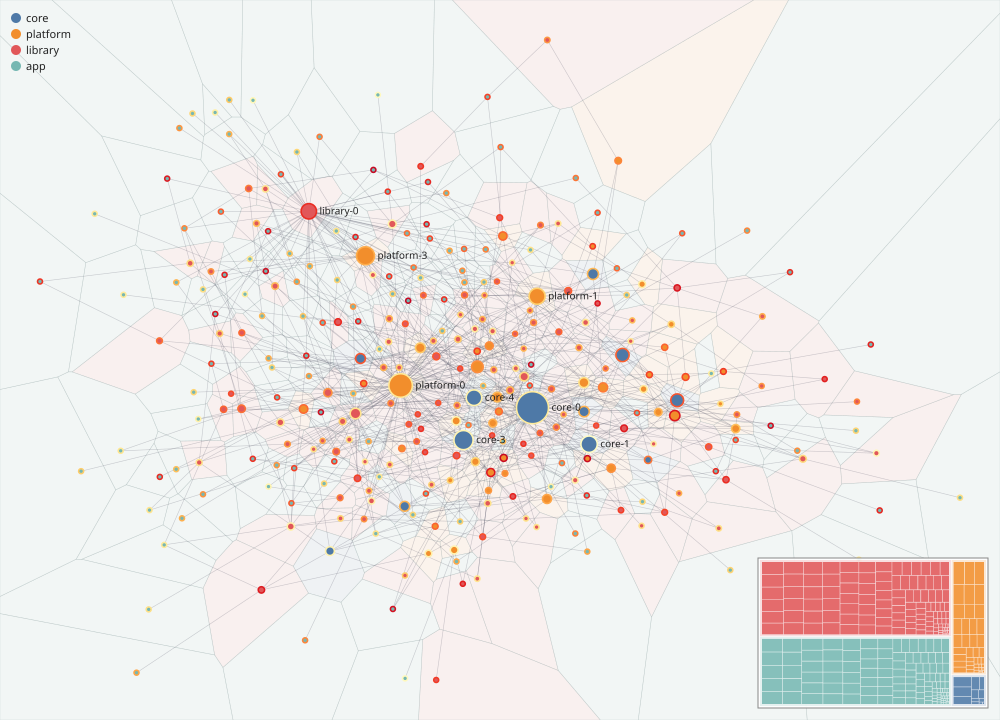

In [6]:
from IPython.display import SVG, display

display(SVG(filename=str(svg_path)))
